# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах.

**Цель исследования**:  модель, которая сможет классифицировать комментарии на позитивные и негативные.

**Оценка качества** :  качество работы модели будет оцениваться метрикой `F1`,  полученная модель должна показывать метрику не меньше 0.75.

**Описание данных**:  для проведения исследования доступен набор данных с разметкой о токсичности правок:

- `text` - текст комментария
- `toxic` — целевой признак

## Загрузка данных и библиотек

###  Импорт библиотек

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno optuna==3.6 optuna-integration stopwordsiso matplotlib==3.8.3 scikit-learn==1.5.2 numpy==1.23.5 numba==0.60.0 -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
from warnings import simplefilter

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pylab import rcParams
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from collections import Counter
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
    StratifiedKFold,
)
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import optuna
from optuna import create_study, Trial, distributions
import stopwordsiso as stopwords

In [3]:
# настройки Pandas
pd.options.display.float_format ='{:,.3f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 512)

# seed для генераторов случайных чисел
SEED = 42

# прогресс-бар
tqdm.pandas()

# настройки графиков
PLOT_DPI = 150
sns.set_theme(style="darkgrid", palette="crest")
rcParams['figure.figsize'] = 12, 6
plt.rc(
       'axes',
       labelweight='bold',
       titlesize=16,
       titlepad=10,
      )

# остальные настройки
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

# путь к директориям
PATH_REMOTE = '/datasets/toxic_comments.csv'
PATH_LOCAL = '/Users/kasper/Documents/TS/toxic_comments.csv'

# словари слов
stopwords = stopwords.stopwords("en")
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

### Чтение данных

<font size="3"> Считаем данные, содержащие комментарии пользователей и сохраним в переменную `text`:

In [4]:
if os.path.exists(PATH_LOCAL):
    text = pd.read_csv(PATH_LOCAL)
    display(text.sample(10))
elif os.path.exists(PATH_REMOTE):
    text = pd.read_csv(PATH_REMOTE)
    display(text.sample(10))
else:
    print('Something is wrong')

,Unnamed: 0,text,toxic
154939,155096,"""\n\nAll this has been cited. Making your """"complaints"""" feeble and unjustified. For someone who claims to be a Luftwaffe unthusiast, for you to calim Caldwell dubious as a source is the best one I have heard from you. \nCaldwell makes a point of reporting losses by the side that suffers them. He always mentions overclaiming.\n2. Specfific dates are given, as you well know. (Either that or you don't read properly)\n3. No it doesn't. It syas RAF Mustangs were included as well.\n4. The context is you have...",0
130472,130608,"Hearing no justification for keeping it, I removed the category today.",0
21884,21904,"""\nWith respect Wikipedia works on the basis of consensus and you alone are not in a position to say when the discussion is closed. That said I would have no problem inserting the same words that you quote viz """"The English Army, founded in 1660, was succeeded in 1707 by the new British Army"""" into this article to give additional context. I hope that helps. """,0
76330,76406,"Got rid of !@#$% verification tags \n\nTo satisfy a certain editor who insisted on scattering useless tags all over the article challenging obvious facts I already showed him before, I've supplied references. Sheesh, and I don't get any thanks for the work I do.",0
2795,2795,"As someone else who works in this building, I'm now annoyed that I can't edit wikipedia -(",0
8225,8237,Reply: I understand. Thanks for explaining!,0
57638,57701,"Thank you for experimenting with the page Tractor kid on Wikipedia. Your test worked, and has been reverted or removed. Please use the sandbox for any other tests you want to do. Take a look at the welcome page if you would like to learn more about contributing to our encyclopedia. A link to the edit I have reverted can be found here: link. If you believe this edit should not have been reverted, please contact me.",0
134656,134794,"Portal:Wine\nHey there, I made a post on WikiProject Wine offering to update the wine portal each month as I update the food portal each month as well. I know you were involved with it, so I just wanted to make sure you didn't have any plans with it.",0
156417,156576,Perhaps you are worth less than a cockroach. Ya think???,1
86771,86852,You are a sock puppet of a disgusting tranny freak.,1


### Изучение данных

<font size="3"> Изучим структуру и полноту полученных данных.

In [5]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


<Axes: >

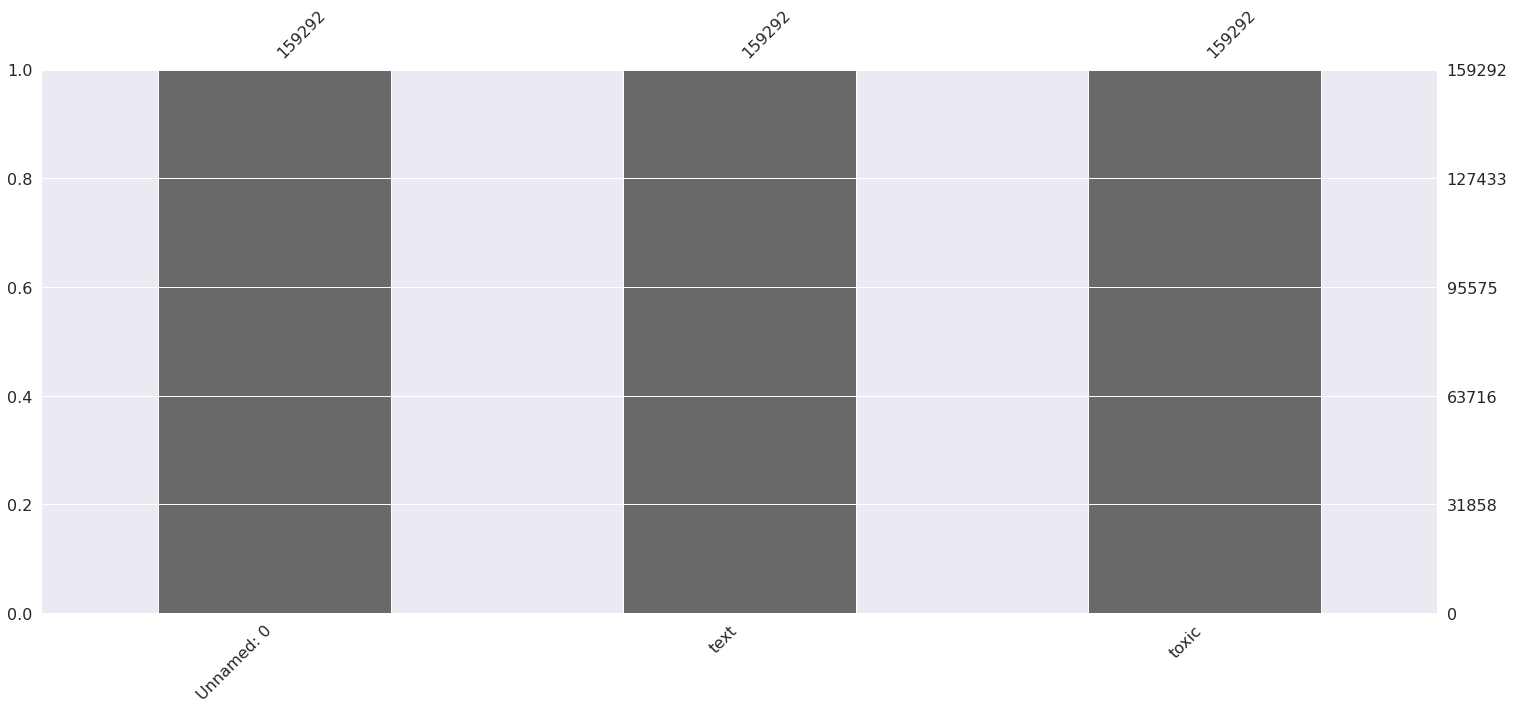

In [6]:
msno.bar(text)

<font size="3">
    
**Вывод**
    
Полученный датафрейм содержит следующие данные:

* `text` — текст комментария;
* `toxic` — целевой признак, индикатор токсичности комментария.

В датафрейме имеется неинформативный столбец `Unnamed: 0`,  который не соответствует индексу (возможно, часть данных была удалена).

Комментарии написаны на английском языке, в тексте присутствуют символы и слова в разном регистре.

Предварительно можно утверждать, что данных достаточно для проведения исследования.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

## Анализ и обработка данных

<font size="3"> Изучим подробнее полученные данные.


### Визуализация целевого признака
    
<font size="3"> Изучим сбалансированность таргета.

0   0.898
1   0.102
Name: toxic, dtype: float64

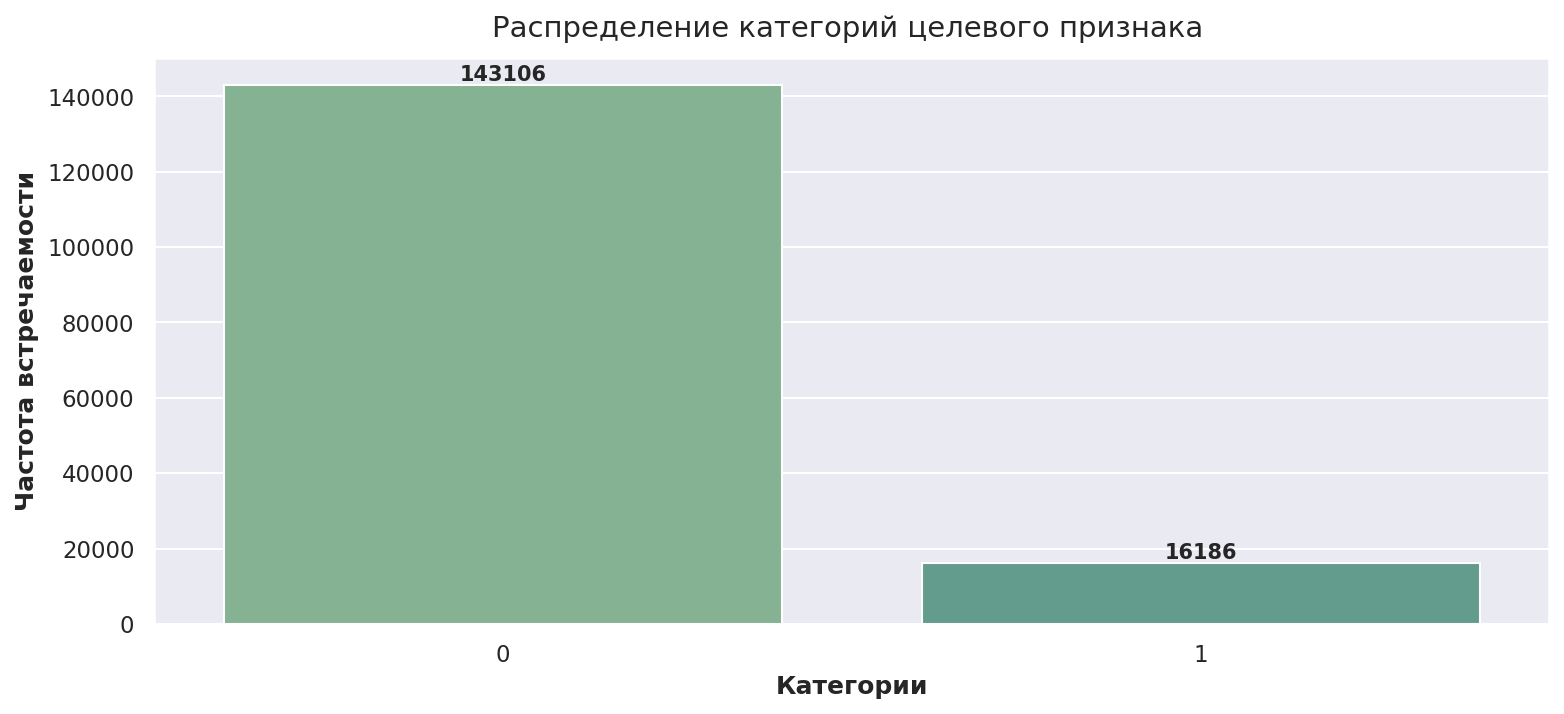

In [7]:
plt.figure(dpi=PLOT_DPI)

ax = sns.countplot(x=text['toxic'],
                   order=text['toxic'].value_counts(ascending=False).index);

abs_values = text['toxic'].value_counts(ascending=False).values

ax.bar_label(container=ax.containers[0], labels=abs_values, fontweight='bold')
ax.set_title('Распределение категорий целевого признака ', fontsize=14)
ax.set_xlabel('Категории', fontweight='bold')
ax.set_ylabel('Частота встречаемости', fontweight='bold')
ax.figure.set_size_inches(12,5)

display(text['toxic'].value_counts(normalize=True))

<font size="3">   
    
**Вывод**
    
Целевой признак `toxic` - индикатор токсичности комментария, представлен категориями `0` и `1`.

Таргет не сбалансирован: 90% комментариев не токсичные и только 10% комментариев токсичные.

Утчём дисбаланс таргета при формировании выборок и обучении моделей.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Формирование выборок

<font size="3"> Разделим данные на обучающую и тестовую выборки. На тест выделим 30% от исходных данных.

In [8]:
# разделим данные на обучающую и тестовую выборки
train_set, test_set = train_test_split(
    text[['text', 'toxic']], 
    test_size=0.3, 
    stratify=text['toxic'],
    random_state=SEED
    )

In [9]:
# проверка размерности выборок
for x in ['train_set', 'test_set']:
    print(f'Размерность {x}: {globals()[x].shape} - {len(globals()[x])/len(text):.0%}')
    
# проверка баланса классов в выборках
print(f'''Баланс классов целевого признака:
train_set:
{round(train_set['toxic'].value_counts()/len(train_set)*100)}
test_set:
{round(test_set['toxic'].value_counts()/len(test_set)*100)}''')

Размерность train_set: (111504, 2) - 70%
Размерность test_set: (47788, 2) - 30%
Баланс классов целевого признака:
train_set:
0   90.000
1   10.000
Name: toxic, dtype: float64
test_set:
0   90.000
1   10.000
Name: toxic, dtype: float64


In [10]:
# удалим оригинальный датафрейм
del text

<font size="3">  

**Вывод**

Исключены неинформативные признаки, выделены обучающая и тестовая выборки.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Дубликаты

<font size="3"> 
<br>Проверим тренировочную выборку на наличие дубликатов.

In [11]:
train_set.duplicated().sum()

0

<font size="3">

**Вывод**
    
Дубликаты отсутствуют.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Анализ длины комментариев
<font size="3">  Изучим распределение длины имеющихся комментариев.

Статистика для класса 0:


count   100,174.000
mean        404.530
std         587.500
min           6.000
25%         102.000
50%         216.000
75%         453.000
max       5,000.000
Name: text, dtype: float64

Статистика для класса 1:


count   11,330.000
mean       299.616
std        614.380
min          5.000
25%         60.000
50%        127.000
75%        278.000
max      5,000.000
Name: text, dtype: float64

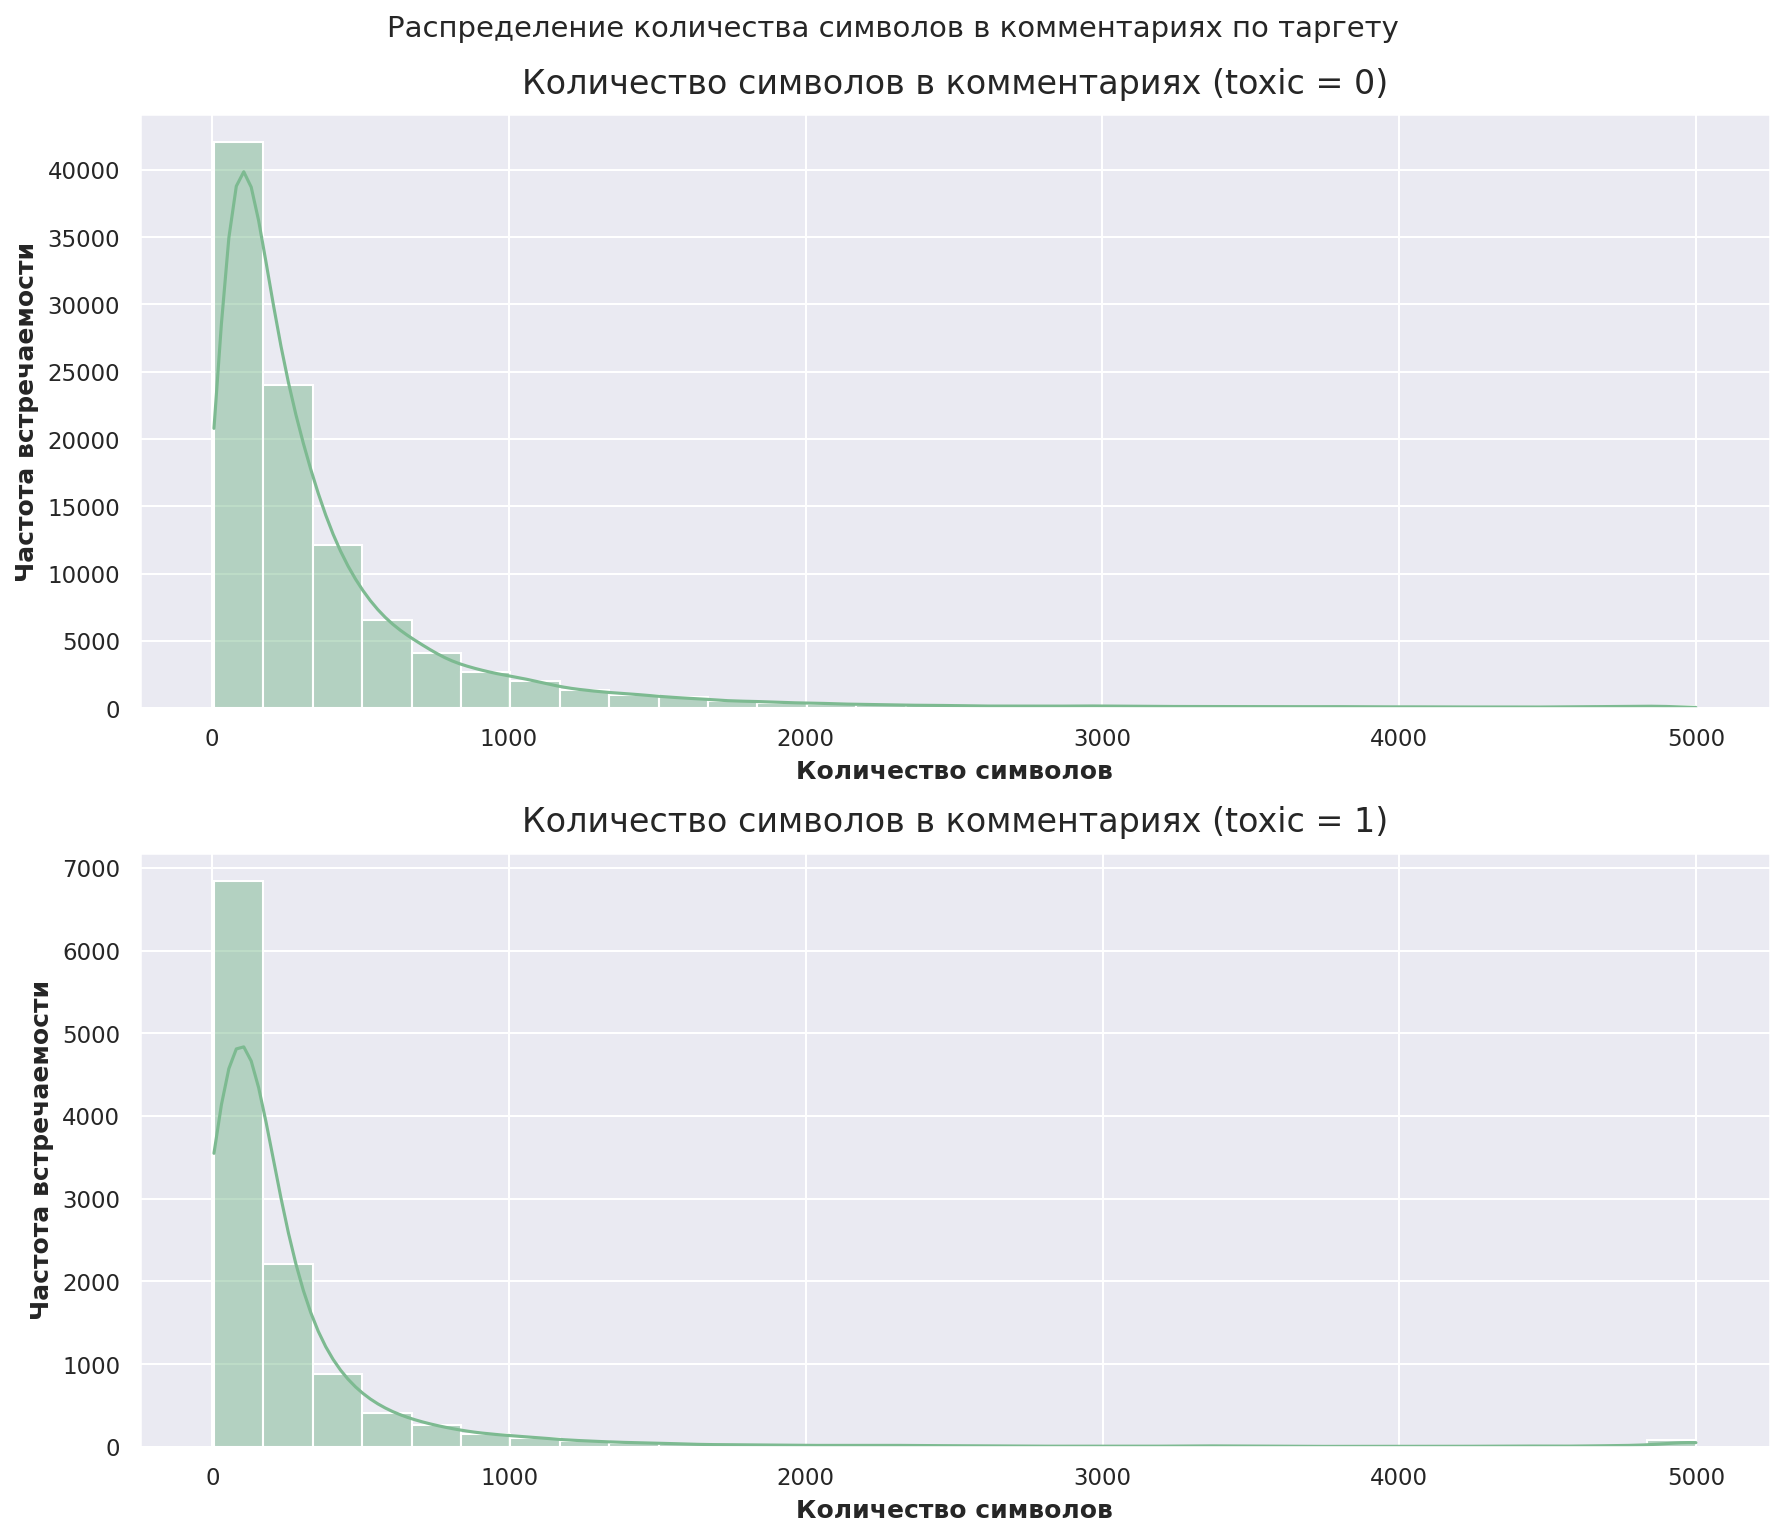

In [12]:
# получим уникальные значения таргета
unique_targets = train_set['toxic'].unique()

# выведем статистики для каждого класса
for target in unique_targets:
    print(f'Статистика для класса {target}:')
    display(train_set[train_set['toxic'] == target]['text'].apply(len).describe())

# визуализируем распределения
fig, axes = plt.subplots(
    nrows=len(unique_targets),
    ncols=1,
    figsize=(12, 5 * len(unique_targets)),
    dpi=PLOT_DPI,
)

for i, target in enumerate(unique_targets):
    sns.histplot(
        data=train_set[train_set['toxic'] == target],
        x=train_set[train_set['toxic'] == target]['text'].apply(len),
        kde=True,
        ax=axes[i],
        bins=30,
    )
    axes[i].set_title(f'Количество символов в комментариях (toxic = {target})')
    axes[i].set_xlabel('Количество символов')
    axes[i].set_ylabel('Частота встречаемости')

plt.tight_layout()
plt.suptitle('Распределение количества символов в комментариях по таргету', fontsize=14, y=1.02)
plt.show()

<font size="3"> Изучим подробнее самые длинные и самые короткие комментарии.

In [13]:
# проверка длинных комментариев
train_set[train_set['text'].map(len) == 5000].head()

,text,toxic
93787,wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wiki NOOBS wi...,1
82496,"MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHAHA, YOU CAN'T STOP MY VANDALISM MUAHAHAHAHAHAHAHAHAHAHAHA...",1
156158,HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE FAGGOT HUGE...,1
56724,"i CAN STILL POST WITH THIS COMPUTER...I SAID BLOCK ME, COME THE FUCK DOWN HERE AND ARREST ME...SAN DIEGO CALIFORNIA, CHULA VISTA, FUCKING GET YOUR INFORMATION RIGHT FAGGOT SHITHEAD!!i CAN STILL POST WITH THIS COMPUTER...I SAID BLOCK ME, COME THE FUCK DOWN HERE AND ARREST ME...SAN DIEGO CALIFORNIA, CHULA VISTA, FUCKING GET YOUR INFORMATION RIGHT FAGGOT SHITHEAD!!i CAN STILL POST WITH THIS COMPUTER...I SAID BLOCK ME, COME THE FUCK DOWN HERE AND ARREST ME...SAN DIEGO CALIFORNIA, CHULA VISTA, FUCKING GET YO...",1
128558,sex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex fucksex ...,1


<font size="3"> Посчитаем количество комментариев с максимальной длинной в разбивке по таргету.

In [14]:
# кол-во длинных комментариев по таргету
train_set[train_set['text'].map(len) == 5000]['toxic'].value_counts()

1    22
0     7
Name: toxic, dtype: int64

<font size="3"> Можно отметить, что в тренировочном датасете максимальная длина комментария указывает на то, что текст носит скорее негативный характер.

In [15]:
# проверка коротких комментариев
train_set[train_set['text'].map(len) <= 10]

,text,toxic
136820,~ J.Lo,0
119018,"""""""",1
118650,FUCK YOU,1
120868,you suck,1
15432,"Howdy!""",0
52336,"14:53,",0
137400,"== """"""",0


<font size="3"> Данные комментарии могут остаться пустыми после очистки текста от символов и стоп-слов. 

Также стоит отметить объект `"""` под индексом **119018**, который не несёт в себе смысла (ни положительного, ни отрицательного), но размечен как негативный комментарий.

<font size="3">
    
**Вывод**

Средняя длина комментариев в выборке: 

- класс `0` - **405** символа;
- класс `1` - **300** символов.

В среднем, нейтральные комментарии длинее токсичных, при этом токсичные комментарии чаще содержат объекты с максимальной длинной - 5000 символов. 

В выборке присутствуют комментарии, повторяющие одну фразу / слово / символ много раз, а также короткие комментарии, которые могут остаться пустыми после очистки данных.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Очистка данных
<font size="3"> Очистим комментарии от символов и стоп-слов, дополнительно приведём текст к нижнему регистру.

In [16]:
def clean_text(text):
    # приведём текст к нижнему регистру
    text = text.lower()
    
    # удалим неалфавитно-цифровые символы
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # удалим HTML-теги
    text = re.sub(r'<[^>]+>', '', text)

    # удалим URL-ссылки
    text = re.sub(r'http\S+', '', text)

    # удалим стоп-слова
    text = " ".join([word for word in text.split() if word not in stopwords])
    
    return text

In [17]:
# очистим данные, результат сохраним в отдельном столбце
train_set['clean_text'] = train_set['text'].apply(clean_text)
test_set['clean_text'] = test_set['text'].apply(clean_text)

In [18]:
# проверим результат
train_set.head()

,text,toxic,clean_text
34381,"""\n\n Have a nice weekend! \n\nNow that the odd business with the Elf article and JMR is long gone, I simple wanted to pass by and drop you a kiss. Have a great weekend! Yes babe? """,0,nice weekend odd business elf article jmr simple pass drop kiss weekend babe
23674,you dont even know the meaning of linkfarm you twat,0,meaning linkfarm twat
30782,Response\nHey! He started it!,0,response hey started
33963,Garland Insurance Agency\nAre you trying to delete Garland Insurance Agency,0,garland insurance agency delete garland insurance agency
137236,"""\nThank you for experimenting with the page Satellite on Wikipedia. Your test worked, and has been reverted or removed. Please use the sandbox for any other tests you want to do. Take a look at the welcome page if you would like to learn more about contributing to our encyclopedia. (talk • contribs • [/wiki/User:Interiot/Tool2/code.js?username= count]) (Respond to me on my Talk.) """,0,experimenting satellite wikipedia reverted removed sandbox tests learn contributing encyclopedia talk contribs wikiuserinteriottoolcodejsusername count respond talk


<font size="3"> Выведем записи с пропусками в очищенном тексте.

In [19]:
train_set[train_set['clean_text'] == ''].sample(5, random_state=SEED)

,text,toxic,clean_text
141701,"Get up, get get, get down",0,
4739,Stop making up information please. 71.239.172.110,0,
101106,"You just don't stop, do you?",0,
21605,Going to get it \n\nYou're going to get it 86.177.136.20,0,
93328,I did. http://img217.imageshack.us/my.php?image=untitled3th1.png it still doesn't work,0,


<font size="3"> Данные объекты утратили все символы после очистки текста. Оставим их в обучающей выборке, чтобы модели научились работать с такими комментариями.

Дополнительно проверим дубликаты после обработки текста.

In [20]:
duplicates = train_set[train_set['clean_text'].duplicated(keep=False)] \
    .sort_values(by='clean_text', key=lambda x: x.str.len())

In [21]:
display(duplicates.shape)
display(duplicates.tail(10))

(4043, 3)

,text,toxic,clean_text
22040,"""]\n\nMalfunctioning archive bot and improper archive page creations?\n\nI do not know why there have been three additional archive pages for my talk page created, none of which is full, since yesterday. I just saw this comment of Sept. 10, 2008, because someone or something placed it in an archive page (25) that did not exist last night or even early this morning. I almost didn't see it at all. Everyone who posts in Wikipedia is a real person; we use log-in identities to protect our privacy and our ...",0,malfunctioning archive bot improper archive creations additional archive talk created yesterday comment sept archive exist night morning posts wikipedia real person login identities protect privacy private identities real wikipedia published version wikipedia internet control practices choosing wikipedia identities aware violates wpagf wpcivil wikipediaetiquette comments ani situations continually posted concerns faith continually set assure contributing wikipedia nyscholar june learn follow wikipedias ...
85222,"""\n\nMalfunctioning archive bot and improper archive page creations?\n\nI do not know why there have been three additional archive pages for my talk page created, none of which is full, since yesterday. I just saw this comment of Sept. 10, 2008, because someone or something placed it in an archive page (25) that did not exist last night or even early this morning. I almost didn't see it at all. Everyone who posts in Wikipedia is a real person; we use log-in identities to protect our privacy and our p...",0,malfunctioning archive bot improper archive creations additional archive talk created yesterday comment sept archive exist night morning posts wikipedia real person login identities protect privacy private identities real wikipedia published version wikipedia internet control practices choosing wikipedia identities aware violates wpagf wpcivil wikipediaetiquette comments ani situations continually posted concerns faith continually set assure contributing wikipedia nyscholar june learn follow wikipedias ...
141615,"""\n\nYou know what, forget it. The guy who was repeatedly changing the opening and led me to post what was previously here, because he repeatedly refused to answer the simple question of why (except of course to start SHOUTING) has reported me for not being civil. How ironic is that. Rather than have a long detailed discussion here about which opening is better, I'll simply point out that in the current version, even after you read the entire first paragraph, you still don't have a clue why this article...",0,forget guy repeatedly changing led post repeatedly refused answer simple question start shouting reported civil ironic detailed discussion simply current version read entire paragraph clue article exists marco rodrguez living yay guess idea deal assuming fallen asleep shot read brazil germany biggest loss variants multiple times people serving article summarises key engaging professional job paid write living garbage justifying poordullrepetitivetrivial writing claim alternatives unencyclopedic frankly ...
4496,"""\n\nYou know what, forget it. The guy who was repeatedly changing the opening and led me to post what was previously here, because he repeatedly refused to answer the simple question of why (except of course to start SHOUTING) has reported me for not being civil. How ironic is that. Rather than have a long detailed discussion here about which opening is better, I'll simply point out that in the current version, even after you read the entire first paragraph, you still don't have a clue why this article...",0,forget guy repeatedly changing led post repeatedly refused answer simple question start shouting reported civil ironic detailed discussion simply current version read entire paragraph clue article exists marco rodrguez living yay guess idea deal assuming fallen asleep shot read brazil germany biggest loss variants multiple times people serving article s

<font size="3"> Выявлены дубликаты, причём идентичные объекты под индексами 147723 и 8911 имеют разный класс, что говорит о возможной неточности разметки.

Удалим найденные дубликаты из выборки.

In [22]:
# удаление дубликатов
train_set = train_set.drop_duplicates('clean_text')

In [23]:
# проверим результат
train_set.shape[0]

108448

In [24]:
# удалим срез данных
del duplicates

<font size="3">
    
**Вывод**

Данные успешно очищены, в результате обработки выполнены преобразования: 
    
- текст приведён к нижнему регистру;
- удалены HTML-теги, URL-ссылки, стоп-слова и неалфавитно-цифровые символы.
    
Дополнительно изучены пропуски и дубликаты, полученные после очистки текста.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Обработка данных
<font size="3"> Проведём токенизацию и лемматизацию очищенных данных.

In [25]:
# выполним токенизацию
train_set['clean_text'] = train_set['clean_text'].apply(word_tokenize)
test_set['clean_text'] = test_set['clean_text'].apply(word_tokenize)

In [26]:
# создадим экземпляр WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [27]:
def penn2morphy(penntag):
    # словарь для соответствия тегов Penn Treebank тегам WordNet
    morphy_tag = {'NN':'n', 'JJ':'a', 'VB':'v', 'RB':'r'}
    try:
        return morphy_tag[penntag[:2]] # соответствующий тег WordNet
    except:
        return 'n' # по умолчанию существительное

In [28]:
def lemmatize_text(tokens):
    # выполним лемматизацию
    lemmas = [
        lemmatizer.lemmatize(token.lower(), pos=penn2morphy(tag))
        for token, tag in pos_tag(tokens)
    ]
    # объединим токены обратно в строку
    return ' '.join(lemmas)

In [29]:
# применим функцию лемматизации
train_set['clean_text'] = train_set['clean_text'].progress_apply(lemmatize_text)
test_set['clean_text'] = test_set['clean_text'].progress_apply(lemmatize_text)

100%|██████████| 47788/47788 [01:21<00:00, 586.44it/s]


In [30]:
# проверим результат
train_set.sample(5, random_state=SEED)

,text,toxic,clean_text
54663,"""\n\n Where is Your """"Wiki-Page""""? \n\nYo Joe, good buddy! What happened to your """"wiki-page""""? How is your ego holding out, you moron. It serves you right for the way that you treated us on Fidonet. Revenge is a dish best served cold, my friend. It might have taken us years to get back at you, Hitler, but it was well worth it.""",1,wikipage yo joe buddy happen wikipage ego hold moron serf treat fidonet revenge dish serve cold friend hitler worth
40361,a dippy lunatic like,1,dippy lunatic
109309,Although the older Nickel Coin (Canada 1958) IS magnetic.,0,nickel coin canada magnetic
159197,"""\n\n URL Update (update to my previous, and only, post) \n\nI checked today and verified that the """"original"""" 'chucknorrisfacts' URL is working (vs. the 'replacement' URL mentioned in my previous post 'thechucknorrisfacts'.)""",0,url update update previous post check verified original chucknorrisfacts url replacement url mention previous post thechucknorrisfacts
153728,"Removed this paragraph from the lead. It is unsourced and reads like opinion.\n\nThe translation is still widely read today, and highly regarded among many Christian groups. Some groups (known collectively as the King-James-Only Movement) even go as far as to reject all modern translations, believing the KJV to be the only reliable English Bible translation. This is despite the translation being almost 400 years old, criticisms of its accuracy, and the fact that it is written in Early Modern English (ma...",0,remove paragraph lead unsourced reads opinion translation read highly regarded christian collectively kingjamesonly movement reject modern translation believe kjv reliable english bible translation translation criticism accuracy write modern english difficult modern english speaker read understand cheer


<font size="3">
    
**Вывод**

В результате обработки для каждого комментария получена строка из лемматизированных слов.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Частотный анализ слов
<font size="3"> Выполним частотный анализ слов в выборке.

In [31]:
def create_corpus(label):
    # собираем все слова из столбца clean_text, где toxic == label
    corpus = ' '.join(train_set[train_set['toxic'] == label]['clean_text'].tolist())
    return corpus

In [32]:
def plot_word_frequency(target):
    # выберем все слова из столбца comments, где toxic == target
    corpus = create_corpus(target)

    # разобьем текст на слова
    words = corpus.split()

    # посчитаем частоту слов
    counter = Counter(words)
    most = counter.most_common()

    # получим список самых частых слов
    x = [word for word, count in most[:30]]
    y = [count for word, count in most[:30]]

    # визуализируем результат
    plt.figure(figsize=(12, 6), dpi=PLOT_DPI)
    sns.barplot(x=y, y=x)
    plt.show()

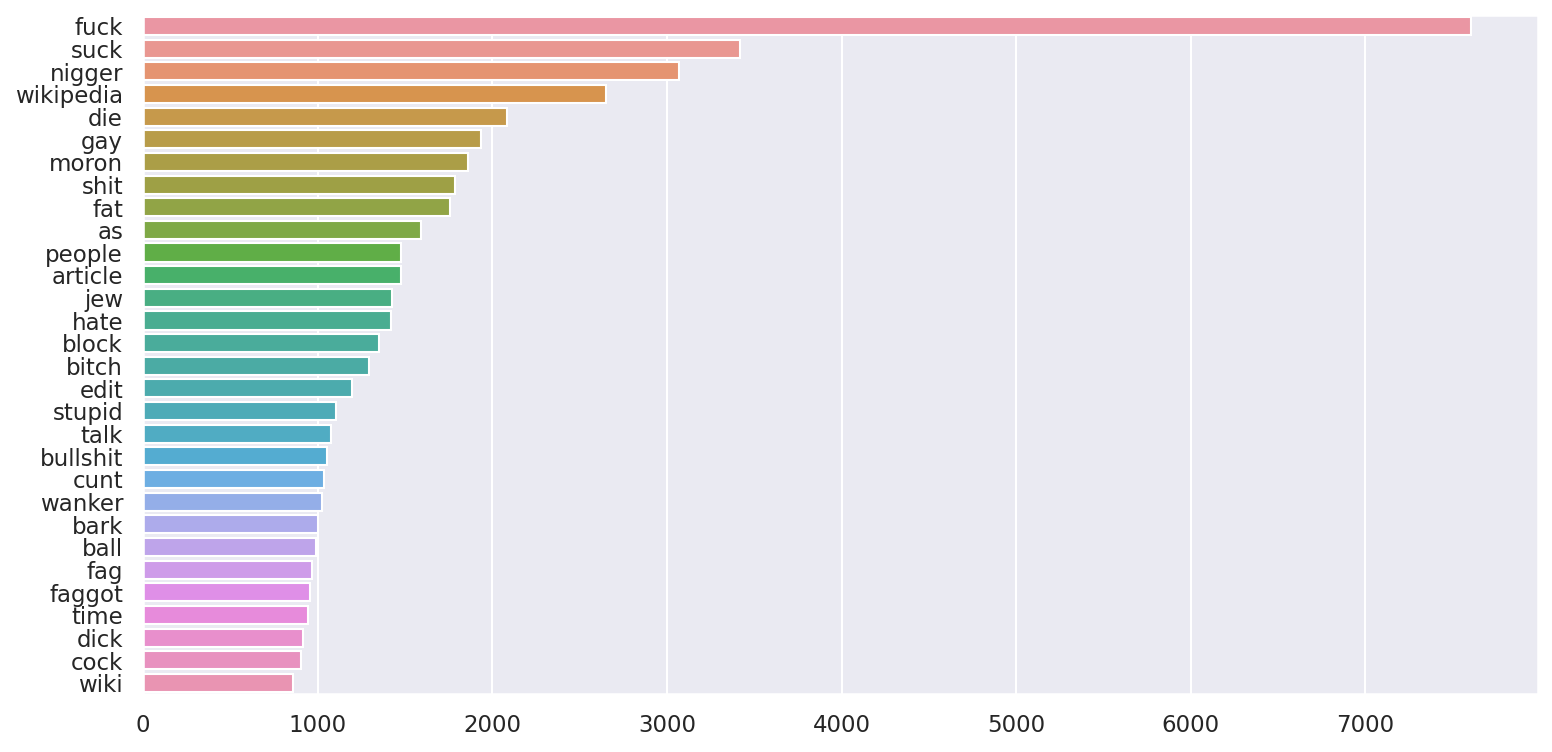

In [33]:
# график для токсичных комментариев (target=1)
plot_word_frequency(1)

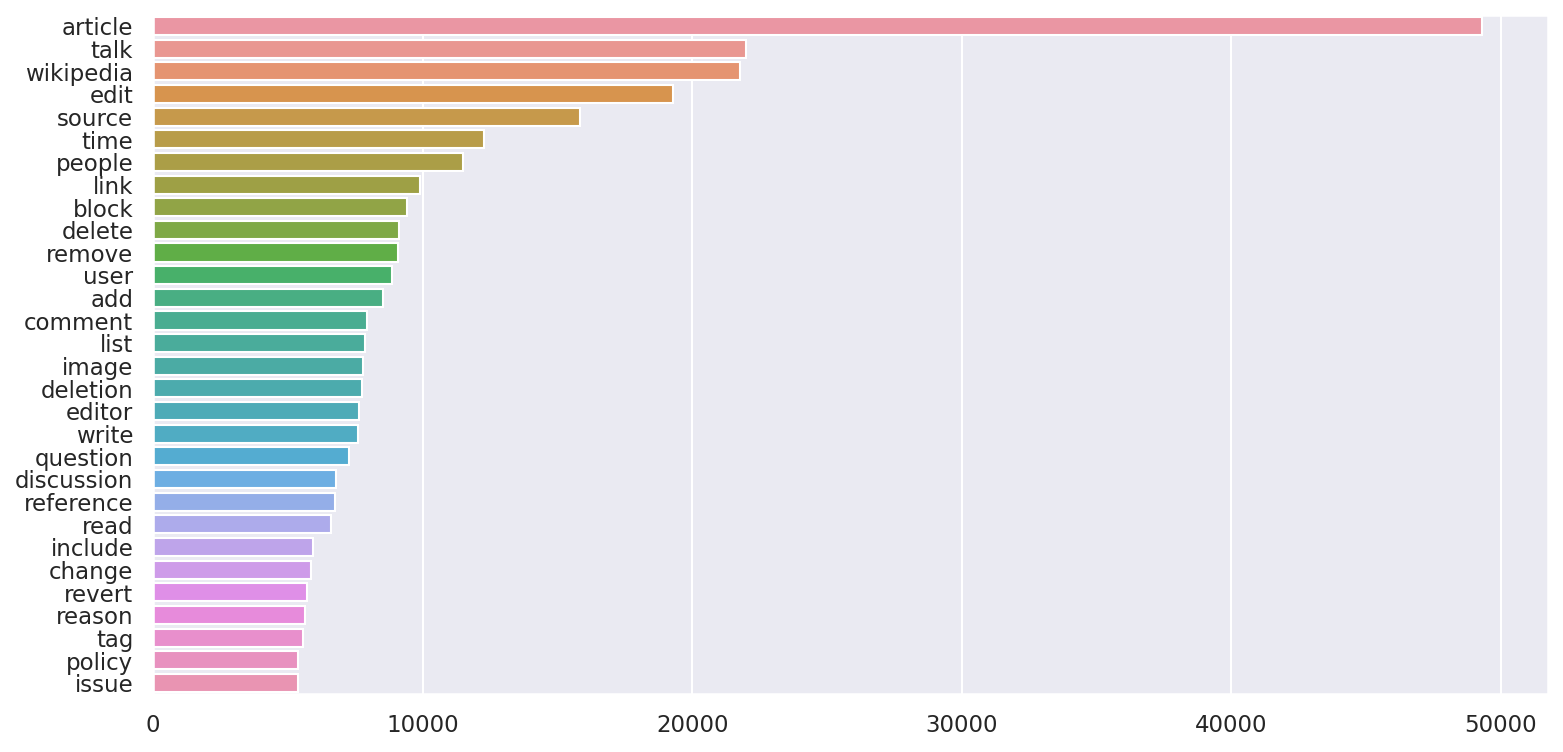

In [34]:
# график для нейтральных комментариев (target=0)
plot_word_frequency(0)

<font size="3">
    
**Вывод**

Построены графики частотности слов в разбивке по таргету: самые частые слова в комментариях соответствуют контексту.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

## Подготовка данных

<font size="3"> Выделим таргет из очищенных выборок и подготовим данные к обучению моделей.

In [35]:
# обозначим входные и целевой признаки
train_features, train_target = train_set['clean_text'], train_set['toxic']
test_features, test_target = test_set['clean_text'], test_set['toxic']

# проверим размерность
print(f'Размер выборок: {train_features.shape};{test_features.shape};{train_target.shape};{test_target.shape}')

Размер выборок: (108448,);(47788,);(108448,);(47788,)


In [36]:
# удалим неактуальные выборки
del train_set
del test_set

<font size="3">  

**Вывод**

Отобраны признаки для построения прогноза, входной признак векторизирован, выделены обучающая и тестовая выборки.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3"> 
    
## Разработка моделей
    
Проведем сравнительный анализ трёх простых моделей:

- `LogisticRegression`
- `SGDClassifier`
- `LinearSVC`

Метрика качества: **F1**.

Для подбора гиперпараметров используем библиотеку `Optuna`.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### LogisticRegression

<font size="3"> Напишем модель логистической регрессии с подбором гиперпараметров.

In [37]:
def objective_log(trial):
    # укажем гиперпараметры модели для перебора
    params_log = {
    'C': trial.suggest_float('C', 5.0, 15.0),
    'max_iter': trial.suggest_int('max_iter', 100, 1000),
    "class_weight": "balanced",
    "random_state": SEED
    }
    
    # создадим pipeline
    model_log = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 1), max_features=None, dtype=np.float32)),
        ('logisticregression', LogisticRegression(**params_log)) 
    ])

    # выполним кросс-валидацию
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores_log = cross_val_score(model_log, train_features, train_target,  scoring='f1', cv=skf, n_jobs=-1)

    # получим среднюю метрику
    return scores_log.mean()

In [38]:
# создадим объект study
study_log = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=10))
# запустим процесс оптимизации
study_log.optimize(objective_log, n_trials=30)

[I 2024-10-09 14:15:39,480] A new study created in memory with name: no-name-2ca7296b-cd7c-4837-98aa-afc76da545aa
[I 2024-10-09 14:17:32,338] Trial 0 finished with value: 0.7515631502790111 and parameters: {'C': 12.713206432667459, 'max_iter': 118}. Best is trial 0 with value: 0.7515631502790111.
[I 2024-10-09 14:19:26,319] Trial 1 finished with value: 0.7527397577762408 and parameters: {'C': 11.336482349262754, 'max_iter': 774}. Best is trial 1 with value: 0.7527397577762408.
[I 2024-10-09 14:21:41,185] Trial 2 finished with value: 0.7515554759784375 and parameters: {'C': 9.985070123025904, 'max_iter': 302}. Best is trial 1 with value: 0.7527397577762408.
[I 2024-10-09 14:23:49,788] Trial 3 finished with value: 0.7508345417417506 and parameters: {'C': 6.98062864759624, 'max_iter': 785}. Best is trial 1 with value: 0.7527397577762408.
[I 2024-10-09 14:26:02,704] Trial 4 finished with value: 0.7505381867099292 and parameters: {'C': 6.691108365625355, 'max_iter': 179}. Best is trial 1 wi

In [39]:
time_log = study_log.best_trial.duration.total_seconds() # время обучения
scores_log = study_log.best_value # метрика модели

# выведем метрику лучшей модели
print('F1 на кросс-валидации:')
scores_log

F1 на кросс-валидации:


0.7529574318354082

<font size="3">

**Вывод**
    
Получены лучшие параметры модели `LogisticRegression()`.

Лучшая метрика **F1** на кросс-валидации: **0.753**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">


### SGDClassifier

<font size="3"> Напишем модель стохастического градиентного спуска с подбором гиперпараметров.

In [40]:
def objective_SGDC(trial):
    # укажем гиперпараметры для перебора
    params_SGDC = {
        'loss': trial.suggest_categorical('loss', ['hinge', 'squared_hinge', 'log_loss', 'modified_huber']),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'optimal', 'invscaling', 'adaptive']),
        'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e-1),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'eta0': trial.suggest_float("eta0", 0.01, 0.5),
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'random_state': SEED
    }
    
    # создадим pipeline
    model_SGDC = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 1), max_features=None, dtype=np.float32)),
        ('sgdclassifier', SGDClassifier(**params_SGDC))
    ])

    # выполним кросс-валидацию
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores_SGDC = cross_val_score(model_SGDC, train_features, train_target, cv=skf, scoring='f1', n_jobs=-1)

    # получим среднюю метрику
    return scores_SGDC.mean()

In [41]:
# создадим объект study
study_SGDC = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=10)) 

# запустим процесс оптимизации
study_SGDC.optimize(objective_SGDC, n_trials=30)

[I 2024-10-09 15:19:27,405] A new study created in memory with name: no-name-3c540dcb-9211-4bec-94d0-aca1b950d3ca
[I 2024-10-09 15:19:44,650] Trial 0 finished with value: 0.7066506068962453 and parameters: {'loss': 'hinge', 'learning_rate': 'adaptive', 'alpha': 4.7472635881072903e-05, 'penalty': 'l2', 'eta0': 0.4771627396355189, 'max_iter': 103}. Best is trial 0 with value: 0.7066506068962453.
[I 2024-10-09 15:20:34,317] Trial 1 finished with value: 0.7002606728194809 and parameters: {'loss': 'squared_hinge', 'learning_rate': 'optimal', 'alpha': 3.7040785712895284e-05, 'penalty': 'l2', 'eta0': 0.2264982554672681, 'max_iter': 491}. Best is trial 0 with value: 0.7066506068962453.
[I 2024-10-09 15:20:54,041] Trial 2 finished with value: 0.21752907242453676 and parameters: {'loss': 'log_loss', 'learning_rate': 'invscaling', 'alpha': 2.3005803026525478e-05, 'penalty': 'l1', 'eta0': 0.41605384989076155, 'max_iter': 142}. Best is trial 0 with value: 0.7066506068962453.
[I 2024-10-09 15:21:08,

In [42]:
time_SGDC = study_SGDC.best_trial.duration.total_seconds() # время обучения
scores_SGDC = study_SGDC.best_value # метрика модели

# выведем метрику лучшей модели
print('F1 на кросс-валидации:')
scores_SGDC

F1 на кросс-валидации:


0.7712892928979693

<font size="3">

**Вывод**
    
Получены лучшие параметры модели `SGDClassifier()`.
    
Лучшая метрика **F1** на кросс-валидации:  **0.771**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">


### LinearSVC

<font size="3"> Напишем модель опорных векторов с подбором гиперпараметров.

In [43]:
# функция подбора гиперпараметров для модели LinearSVC
def objective_SVC(trial):
    # укажем гиперпараметры для перебора
    params_SVC = {
        'C': trial.suggest_float('C', 5.0, 15.0),
        'penalty': trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight":"balanced",
        'max_iter': 100,
        'random_state': SEED
    }
    
    # создадим pipeline
    model_SVC = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 1), max_features=None, dtype=np.float32)),
        ('linearsvc', LinearSVC(**params_SVC))
    ])

    # выполним кросс-валидацию
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores_SVC = cross_val_score(model_SVC, train_features, train_target, cv=skf, scoring='f1', n_jobs=-1)

    # получим среднюю метрику
    return scores_SVC.mean()

In [44]:
# создадим объект study
study_SVC = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=10))

# запустим процесс оптимизации
study_SVC.optimize(objective_SVC, n_trials=30)

[I 2024-10-09 15:28:26,220] A new study created in memory with name: no-name-b5c310cf-e7fd-410d-85c1-ba6eae55dec1
[I 2024-10-09 15:28:44,764] Trial 0 finished with value: 0.7224046815196493 and parameters: {'C': 12.713206432667459, 'penalty': 'l2'}. Best is trial 0 with value: 0.7224046815196493.
[I 2024-10-09 15:29:07,221] Trial 1 finished with value: 0.7111972092589914 and parameters: {'C': 12.488038825386118, 'penalty': 'l1'}. Best is trial 0 with value: 0.7224046815196493.
[I 2024-10-09 15:29:28,431] Trial 2 finished with value: 0.7221125297211973 and parameters: {'C': 6.98062864759624, 'penalty': 'l1'}. Best is trial 0 with value: 0.7224046815196493.
[I 2024-10-09 15:29:46,488] Trial 3 finished with value: 0.7307322511069865 and parameters: {'C': 5.883398141740103, 'penalty': 'l2'}. Best is trial 3 with value: 0.7307322511069865.
[I 2024-10-09 15:30:04,579] Trial 4 finished with value: 0.731888068590899 and parameters: {'C': 5.039482663279145, 'penalty': 'l2'}. Best is trial 4 wit

In [45]:
time_SVC = study_SVC.best_trial.duration.total_seconds() # время обучения
scores_SVC = study_SVC.best_value # метрика модели

# выведем метрику лучшей модели
print('F1 на кросс-валидации:')
scores_SVC

F1 на кросс-валидации:


0.7326177559917205

<font size="3">

**Вывод**
    
Получены лучшие параметры модели `LinearSVC()`.
    
Лучшая метрика **F1** на кросс-валидации:  **0.733**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
## Выбор лучшей модели
    
<font size="3">
    
<br> Для удобства соберём полученные метрики моделей в сравнительную таблицу.

In [46]:
results = pd.DataFrame(
    {'Модели': ['LogisticRegression', 'SGDC', 'SVC'], 
     'F1 на CV': [scores_log, scores_SGDC, scores_SVC],
     'Время обучения': [time_log, time_SGDC, time_SVC]
    })

results

,Модели,F1 на CV,Время обучения
0,LogisticRegression,0.753,139.458
1,SGDC,0.771,18.071
2,SVC,0.733,18.018


<font size="3"> Для  получения прогноза выберем модель **SGDC**, обученную на векторах TF-IDF.

Модель показала оптимальное соотношение скорости обучения и качества прогноза: 
- метрика **F1** модели на кросс-валидации - **0.756**;
- скрорость обучения модели - **1.321** секунд.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="4">
    
**Анализ качества предсказания модели на тестовой выборке**

<font size="3">
        
Получим метрику лучшей модели на тестовой выборке.

In [ ]:
# получим лучшие параметры модели
best_params = study_SGDC.best_params

# создадим модель
tuned_model_SGDC = SGDClassifier(**best_params, random_state=SEED)

In [49]:
# векторизируем входные признаки
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=None, dtype=np.float32)
train_features = vectorizer.fit_transform(train_features)
test_features = vectorizer.transform(test_features)

# обучим модель
tuned_model_SGDC.fit(train_features, train_target)

SGDClassifier(alpha=1.2045949096290168e-05, eta0=0.07995072589220335,
              learning_rate='adaptive', loss='squared_hinge', max_iter=350,
              random_state=42)

In [50]:
# получим предсказания на тестовом наборе
preds = tuned_model_SGDC.predict(test_features)

In [51]:
# получим метрики на тестовом наборе
cr_SGDC = classification_report(test_target, preds, output_dict=True, zero_division=0)

In [52]:
# выведем результат
pd.DataFrame(cr_SGDC).transpose()

,precision,recall,f1-score,support
0,0.966,0.990,0.978,"42,932.000"
1,0.885,0.690,0.776,"4,856.000"
accuracy,0.959,0.959,0.959,0.959
macro avg,0.925,0.840,0.877,"47,788.000"
weighted avg,0.958,0.959,0.957,"47,788.000"


<font size="3"> 

**Вывод**
- качество лучшей модели по метрике `F1` на тестовой выборке - **0.776**;   
- полученная модель точнее предсказывает отрицательный (`0`) класс, чем положительный (`1`);
- полнота (`recall`) охвата положительного (`1`) класса лучшей моделью составляет **0.690**, что означает, что модель правильно определяет около 69% токсичных комментариев.
    
Значение метрики `F1` на тестовой выборке соответствует установленному заказчиком максимальному порогу в **0.75**, что делает выбранную модель пригодной для получения прогноза.
    
Также стоит отметить, что метрики качества модели на тестовых данных соответствуют метрикам, полученным на кросс-валидации, что говорит об отсутствии переобучения.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="4">
    
**Проверка модели на адекватность**

<font size="3"> Для оценки адекватности лучшей модели создадим базовую модель `RidgeClassifier`. 

In [53]:
# создадим базовую модель
model = RidgeClassifier(alpha=0.5, random_state=SEED)

# обучим модель
model.fit(train_features, train_target)

# получим прогноз
preds_base = model.predict(test_features)

In [54]:
# оценим качество модели
cr_base = classification_report(test_target, preds_base, output_dict=True, zero_division=0)

pd.DataFrame(cr_base).transpose()

,precision,recall,f1-score,support
0,0.955,0.993,0.974,"42,932.000"
1,0.902,0.587,0.711,"4,856.000"
accuracy,0.952,0.952,0.952,0.952
macro avg,0.928,0.790,0.842,"47,788.000"
weighted avg,0.950,0.952,0.947,"47,788.000"


<font size="3"> 

**Вывод**
    
Модель `SGDClassifier` справляется c классификацией токсичных комментариев значительно лучше базовой модели `RidgeClassifier`.
    
Лучшая модель исследования является адекватной и может быть использована для получения прогноза.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
## Общий вывод
    
<font size="3">
    
<br> Целью данного исследования являлась разработка инструмента для выявления токсичных комментариев в интернет-магазине "Викишоп".
    
> **Анализ и обработка данных**

- проведен анализ целевого признака, выявлен сильный дисбаланс классов;
- данные предварительно разбиты на обучающую и тестовую выборки;
- проведена начальная предобработка: данные проверены на пропуски, аномальные значения, дубликаты;
- комментарии очищены с помощью регулярных выражений;
- проведена токенизация и лемматизация очищенных текстов;
- выполнен частотный анализ слов: самые частые слова в комментариях соответствуют контексту;
- тексты преобразованы в векторное представление с помощью `TfidfVectorizer`.
    
> **Выбор модели**

Выбраны 3 простых модели:
  - LogisticRegression()
  - SGDClassifier()
  - LinearSVC()

Подбор гиперпараметров для моделей выполнялся с помощью `Optuna`.
<br> Для оценки качества модели выбрана метрика `F1`. 

Лучшие метрики на кросс-валидационных данных получены с помощью модели `SGDClassifier()`:
- F1 - **0.756**;
- скорость обучения - **1.116**

Решено использовать данную модель для получения прогноза.
    
> **Проверка качества модели на тестовых данных**  

Метрики качества модели на тестовых данных соответствуют метрикам, полученным на кросс-валидации, что говорит об отсутствии переобучения.

Удалось достичь следующих значений метрик:
- F1 для положительного класса в **0.766**;
- Precision для положительного класса в **0.895**;
- Recall для положительного класса в **0.670**.

> **Проверка модели на адекватность** 
    
Для оценки адекватности полученной лучшей модели написана базовая модель `RidgeClassifier`.
<br> Модель `SGDClassifier` справляется c классификацией токсичных комментариев значительно лучше базовой модели `RidgeClassifier`.
<br> Лучшая модель исследования является адекватной и может быть использована для получения прогноза.
    
> **Заключение**

Результат работы полученной в ходе исследования модели можно считать удовлетворительным. 

Рекомендации по улучшению: 
- проверить разметку целевого класса, уточнить критерии "токсичности" и убедиться, что данные размечены корректно;
- приоритетом задачи является выявление потенциально токсичных комментариев, стоит рассмотреть `Recall` в качестве основной метрики;
- устранить дисбаланс классов: добавить новые объекты положительного класса или увеличить экземпляры класса искусственно, например, через аугментацию;
- для подготовки данных к обучению можно применить более продвинутые предобученные методы обработки текстов, например, BERT.